In [1]:
import pandas as pd
import scipy.stats as sp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
df = pd.read_csv ("data/academia.csv")

In [3]:
# descriptive statistics
df_desc = df [["paywall_trans", "paywall_menopause"]] .describe ()
df_desc

,paywall_trans,paywall_menopause
count,20.000000,20.000000
mean,46.747500,36.695000
std,86.331926,66.202379
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,40.712500,40.712500
max,238.000000,184.000000


In [4]:
# counting true and false values from clinical effects

# trans

transt = df ['clinical_effects_trans'] .values .sum ()  
transf = (~df ['clinical_effects_trans']) .values .sum () 

# menopause

menot = df ['clinical_effects_menopause'] .values .sum () 
menof = (~df ['clinical_effects_menopause']) .values .sum ()

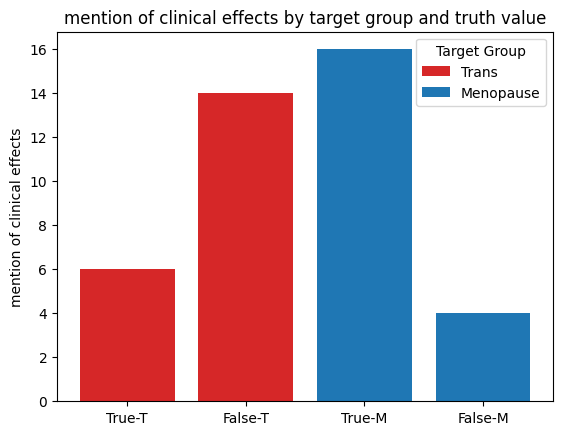

In [5]:
# making barchart

fig, ax = plt.subplots()

clinical_effects = ['True-T', 'False-T', 'True-M', 'False-M']
counts = [transt, transf, menot, menof]
bar_labels = ['_red', 'Trans', '_blue', 'Menopause']  # using '_' to ignore in key
bar_colors = ['tab:red', 'tab:red', 'tab:blue', 'tab:blue']

ax .bar (clinical_effects, counts, label = bar_labels, color = bar_colors)

ax .set_ylabel ('mention of clinical effects')
ax .set_title ('mention of clinical effects by target group and truth value')
ax .legend (title = 'Target Group')

plt .show ()

In [6]:
# creating transgender and menopause datasets excluding zeroes

sup0_trans = df [df ["paywall_trans"] > 0]
sup0_meno = df [df ["paywall_menopause"] > 0]

# finding the modes of the trans and menopause paywalls from the sup0 sets

trans_mode = sup0_trans ["paywall_trans"] .mode ()
meno_mode = sup0_meno ["paywall_menopause"] .mode ()

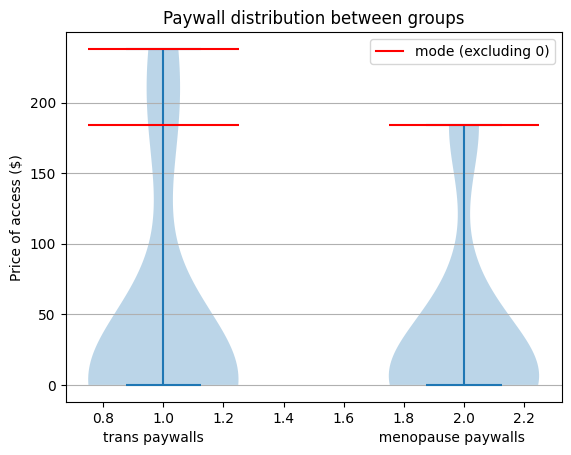

In [7]:
# making the violinplot

fig, ax = plt .subplots ()

ax .violinplot (df [["paywall_trans", "paywall_menopause"]],
                  showmeans = False,
                  showmedians = False)

# showing the trans and menopause modes

ax .hlines (trans_mode, 0.75, 1.25, color = "red")
ax .hlines (meno_mode, 1.75, 2.25, color = "red")

# cosmetics

ax .set_title ('Paywall distribution between groups')
ax .yaxis .grid (True)
ax .set_xlabel ('trans paywalls                                        menopause paywalls')
ax .set_ylabel ('Price of access ($)')

# creating the key

red_line = mlines .Line2D ([], [], color = 'red', label = 'mode (excluding 0)')
ax .legend (handles = [red_line])

plt .show ()

In [8]:
# performing t-test

t_test = sp.ttest_ind (df ["paywall_trans"], df ["paywall_menopause"], alternative = "two-sided")
t_test

TtestResult(statistic=np.float64(0.41322577323369897), pvalue=np.float64(0.6817638513515134), df=np.float64(38.0))